Beginning analytical solution using NumPy's linear algebra functions...
Computing eigenvalues and eigenvectors...
Eigenvalues: [-2.00000000e-02+0.j         -1.00000000e-02+0.j
 -1.00000000e-02+0.j         -1.46074334e+01+0.j
 -9.33116752e+00+0.j         -1.94115250e-02+0.j
 -3.93198759e+00+0.j         -6.00000000e-02+0.33406586j
 -6.00000000e-02-0.33406586j]


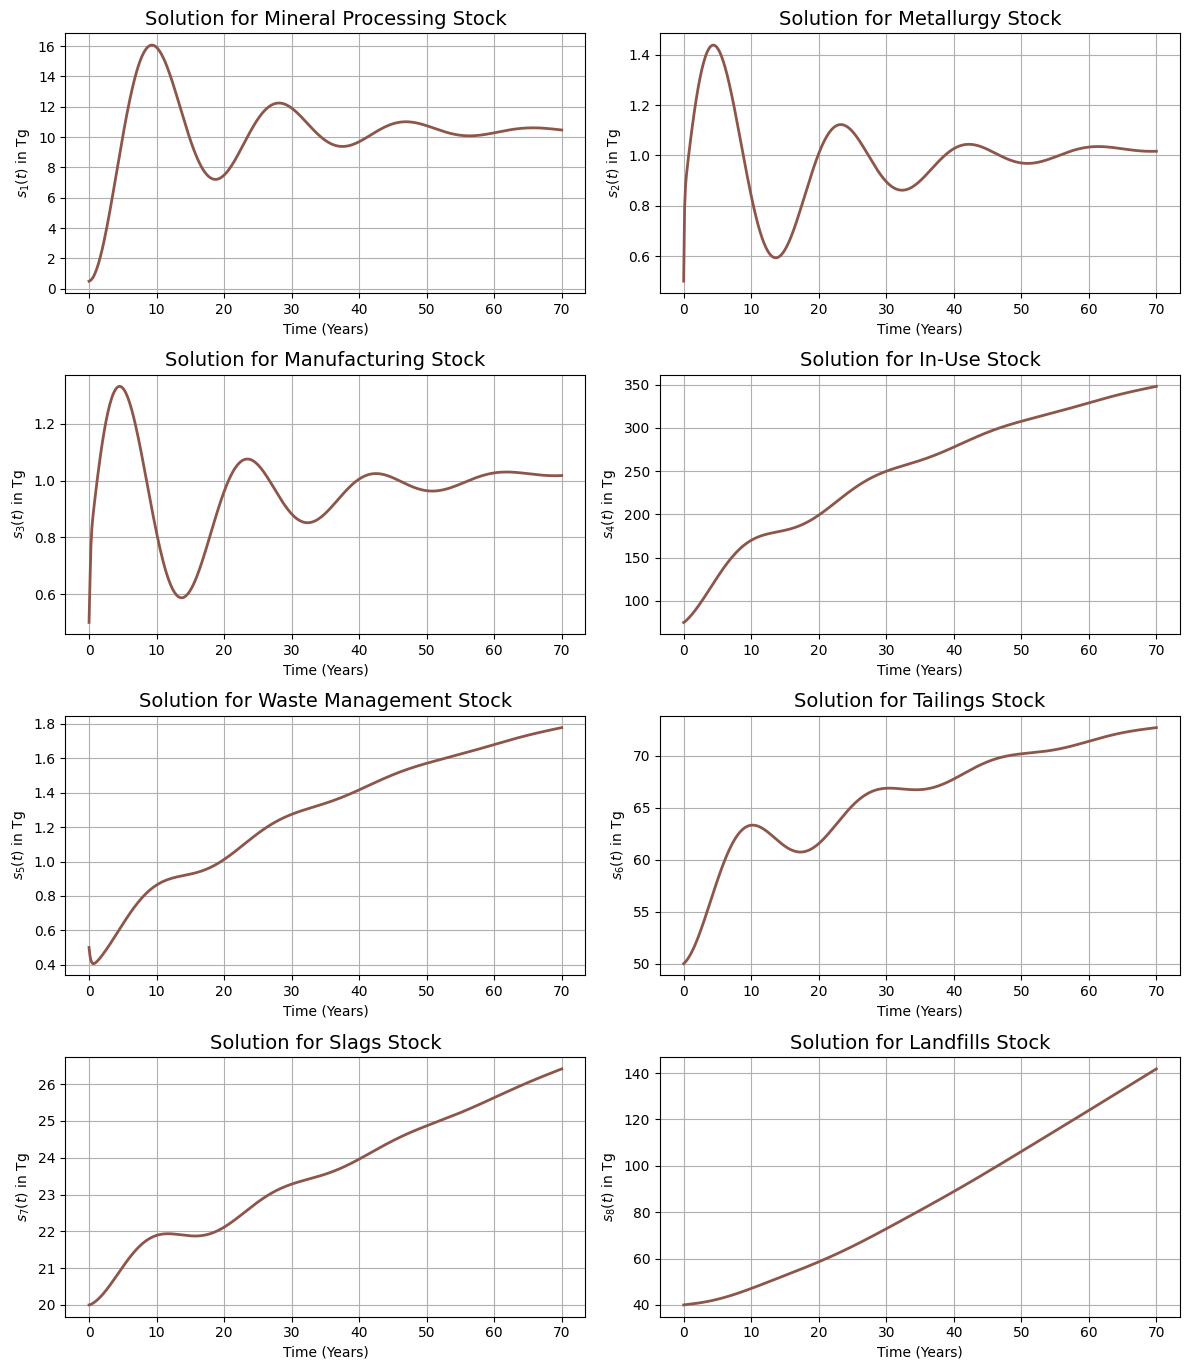

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def solve_and_plot_ode_system_analytical():
    """
    Solves a 9x9 non-homogenous linear system of ODEs analytically
    using NumPy to compute eigenvalues and eigenvectors.
    """

    print("Beginning analytical solution using NumPy's linear algebra functions...")

    # --- 1. Define Numerical Parameters and Matrices ---
    a = 2.5  #3
    beta = 0.2 #0.2
    gamma = 0.6 #0.6
    rho = 1  #1
    b = 0.6  #0.6
    c = 0.15
    alpha2 = 11.20
    alpha3 = 0.60
    alpha5 = 0.01
    alpha6 = 0.33
    alpha7 = 0
    alpha8 = 11.80
    alpha9 = 0.02
    alpha10 = 0
    alpha11 = 1.80
    alpha12 = 0
    alpha13 = 0.70
    alpha14 = 1.40
    alpha15 = 0.01
    alpha16 = 0.01
    alpha17 = 0.01
    alpha18 = 0.01
    alpha19 = 0.01
    alpha20 = 0.01
    alpha21 = 0.01
    alpha22 = 0.01

    # Coefficient Matrix A
    A_matrix = np.array([
        [-gamma * (1 - (beta * rho) / (1 - b - c)), -beta * gamma * (1 - (alpha15 * rho) / (1 - b - c)), 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0],
        [b / (1 - b - c), (b * alpha15) / (1 - b - c), -alpha2 - alpha6 - alpha16, alpha3, 0, alpha14, 0, alpha7, 0], ##
        [0, 0, alpha2, -alpha3 - alpha8 - alpha10 - alpha17, 0, alpha13, 0, 0, 0],
        [0, 0, 0, alpha8, -alpha9 - alpha18, 0, 0, 0, 0],
        [0, 0, 0, alpha10, alpha9, -alpha11 - alpha13 - alpha14 - alpha19, 0, 0, alpha12],
        [c / (1 - b - c), (c * alpha15) / (1 - b - c), 0, 0, 0, 0, -alpha5 - alpha20, 0, 0],
        [0, 0, alpha6, 0, 0, 0, 0, -alpha7 - alpha21, 0],
        [0, 0, 0, 0, 0, alpha11, 0, 0, -alpha12 - alpha22]
    ])

    # Non-homogeneous vector b
    b_vector = np.array([
        (a * beta * gamma * rho) / (1 - b - c),
        0,
        a * (1 + b / (1 - b - c)),
        0,
        0,
        0,
        (a * c) / (1 - b - c),
        0,
        0
    ])

    # Initial conditions
    x0 = np.array([0.1, 0.5, 0.5, 0.5, 75, 0.50, 50, 20, 40])

    # --- 2. Find Eigenvalues and Eigenvectors ---
    print("Computing eigenvalues and eigenvectors...")
    eigenvalues, eigenvectors = np.linalg.eig(A_matrix)
    print("Eigenvalues:", eigenvalues)
    # --- 3. Calculate the Particular Solution ---
    y_p = -np.linalg.solve(A_matrix, b_vector)

    # --- 4. Solve for the Coefficients (c_i) ---
    c = np.linalg.solve(eigenvectors, x0 - y_p)

    # --- 5. Define the Analytical Solution Function ---
    def analytical_solution(t):
        """
        Constructs and evaluates the complete analytical solution at time t.
        """
        y_homogeneous = np.sum(
            [c[i] * eigenvectors[:, i] * np.exp(eigenvalues[i] * t)
             for i in range(len(eigenvalues))], axis=0
        )
        return np.real(y_homogeneous + y_p)

    # --- 6. Plotting the Solutions ---
    t_eval = np.linspace(0, 70, 500)
    y_analytical = np.array([analytical_solution(t) for t in t_eval])

    plt.style.use('default')

    # Create a 2x4 grid for the 8 plots
    fig, axes = plt.subplots(4, 2, figsize=(12, 15))

    axes = axes.flatten()

    # Plot variables s1 to s8 (indices 1 to 8 in the y_analytical array)
    for i in range(8): # Iterate 8 times for s1 to s8
        axes[i].plot(t_eval, y_analytical[:, i+1], 'tab:brown', label=f's{i+1}(t)', linewidth=2)
        if i+1 == 1:
          axes[i].set_title(f'Solution for Mineral Processing Stock', fontsize=14)
        elif i+1 == 2:
          axes[i].set_title(f'Solution for Metallurgy Stock', fontsize=14)
        elif i+1 == 3:
          axes[i].set_title(f'Solution for Manufacturing Stock', fontsize=14)
        elif i+1 == 4:
          axes[i].set_title(f'Solution for In-Use Stock', fontsize=14)
        elif i+1 == 5:
          axes[i].set_title(f'Solution for Waste Management Stock', fontsize=14)
        elif i+1 == 6:
          axes[i].set_title(f'Solution for Tailings Stock', fontsize=14)
        elif i+1 == 7:
          axes[i].set_title(f'Solution for Slags Stock', fontsize=14)
        elif i+1 == 8:
          axes[i].set_title(f'Solution for Landfills Stock', fontsize=14)
        axes[i].set_xlabel('Time (Years)')
        axes[i].set_ylabel(f'$s_{{{i+1}}}(t)$ in Tg')
        axes[i].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

if __name__ == "__main__":
    solve_and_plot_ode_system_analytical()

In [ ]:
    # --- 1. Define Numerical Parameters and Matrices ---
    a = 2.5  #3
    beta = 0.008 #0.008
    gamma = 0.6 #0.6
    rho = 6  #1
    b = 0.8  #0.6
    c = 0.15
    alpha2 = 11.20
    alpha3 = 0.60
    alpha5 = 0.01
    alpha6 = 0.33
    alpha7 = 0.01  #0
    alpha8 = 11.80
    alpha9 = 0.02
    alpha10 = 0.01 #0
    alpha11 = 1.80
    alpha12 = 0.01 #0
    alpha13 = 0.70
    alpha14 = 1.40
    alpha15 = 0.01
    alpha16 = 0.01
    alpha17 = 0.01
    alpha18 = 0.01
    alpha19 = 0.01
    alpha20 = 0.01
    alpha21 = 0.01
    alpha22 = 0.01

    # Coefficient Matrix A
    A_matrix = np.array([
        [-gamma * (1 - (beta * rho) / (1 - b - c)), -beta * gamma * (1 - (alpha15 * rho) / (1 - b - c)), 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0],
        [b / (1 - b - c), (b * alpha15) / (1 - b - c), -alpha2 - alpha6 - alpha16, alpha3, 0, alpha14, 0, alpha7, 0], ##
        [0, 0, alpha2, -alpha3 - alpha8 - alpha10 - alpha17, 0, alpha13, 0, 0, 0],
        [0, 0, 0, alpha8, -alpha9 - alpha18, 0, 0, 0, 0],
        [0, 0, 0, alpha10, alpha9, -alpha11 - alpha13 - alpha14 - alpha19, 0, 0, alpha12],
        [c / (1 - b - c), (c * alpha15) / (1 - b - c), 0, 0, 0, 0, -alpha5 - alpha20, 0, 0],
        [0, 0, alpha6, 0, 0, 0, 0, -alpha7 - alpha21, 0],
        [0, 0, 0, 0, 0, alpha11, 0, 0, -alpha12 - alpha22]
    ])

eigenvalues, eigenvectors = np.linalg.eig(A_matrix)
print((1-b-c)/rho)
print("a11", -gamma * (1 - (beta * rho) / (1 - b - c)))
print("a12", -beta * gamma * (1 - (alpha15 * rho) / (1 - b - c)))

0.008333333333333326
a11 -0.023999999999999553
a12 0.0009600000000000039


In [ ]:
# Loop to print each eigenvalue with its eigenvector


for i in range(len(eigenvalues)):
    eigval = eigenvalues[i]
    eigvec = np.real(eigenvectors[:, i])  # Real part to handle any tiny imaginary artifacts
    print(f"Eigenvalue {i}: {eigval}")
    print(f"Eigenvector: {eigvec}")
    print("---")  # Separator for readability

Eigenvalue 0: -0.02
Eigenvector: [0. 0. 0. 0. 0. 0. 1. 0. 0.]
---
Eigenvalue 1: -14.61095372187348
Eigenvector: [-1.79315664e-19 -1.65895459e-17 -1.50361876e-01  7.68497304e-01
 -6.21925586e-01  4.44267574e-04  1.11153254e-19  3.40069746e-03
 -5.48066732e-05]
---
Eigenvalue 2: -9.341596493835306
Eigenvector: [ 1.43350781e-19  1.61223846e-17 -1.67742893e-01 -6.10682938e-01
  7.73880040e-01 -1.72584691e-03 -1.91505427e-19  5.93837706e-03
  3.33260986e-04]
---
Eigenvalue 3: -3.9329253831475843
Eigenvector: [-1.73678543e-20 -3.35835486e-18  1.32030511e-01  2.25442534e-01
 -6.81596916e-01  6.20865554e-01  9.35497287e-20 -1.11349091e-02
 -2.85606775e-01]
---
Eigenvalue 4: 0.02122649545167382
Eigenvector: [0.00164169 0.07734174 0.00424689 0.00413021 0.95139218 0.00545672
 0.17574462 0.0339945  0.23824736]
---
Eigenvalue 5: -0.04522649545167282
Eigenvector: [-0.00188994  0.04178829 -0.00159486 -0.00121159  0.93893722  0.00409903
  0.17506056  0.02086314 -0.29248038]
---
Eigenvalue 6: -0.009999

In [ ]:
eigenvalues[4], eigenvectors[:,4]

(np.float64(0.02122649545167382),
 array([0.00164169, 0.07734174, 0.00424689, 0.00413021, 0.95139218,
        0.00545672, 0.17574462, 0.0339945 , 0.23824736]))